In [ ]:
## imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import ( StandardScaler,
                                    OneHotEncoder,
                                    PolynomialFeatures
                
)


In [ ]:
## import dataset

df = pd.read_csv("../data/machine_failure_dataset_cleaned.csv")

# **ANALYSING, CLEANING & EDA**

ANALYSIS

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.shape

In [ ]:
df.columns

In [ ]:
## Pipeline (Simple imputer) will deal with null values

df.isnull().sum()

CLEANING

In [ ]:
## removing unwanted columns

df = df.drop("product_ID", axis=1)

FEATURE ORGANIZATION

In [ ]:
## defining target columns
target_columns = ["tool_wear_failure", "power_failure", "overstrain_failure"]


In [ ]:
df[target_columns].value_counts()

In [ ]:
## separating numerical and categorical


numerical_columns = ["air_temperature_k",
                     "process_temperature_k",
                     "rotational_speed_rpm",
                     "torque_nm",
                     "tool_wear_min"
                     

]
categorical_columns = [
                        "product_type",
]

EXPORATORY DATA ANALYSIS

DISTRIBUTION 
- help up understand how the data is distributed

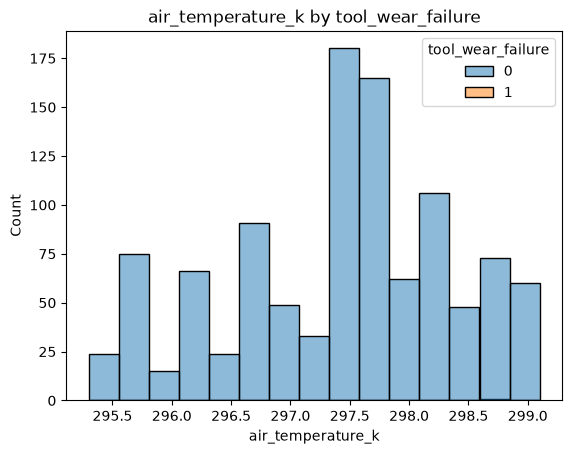

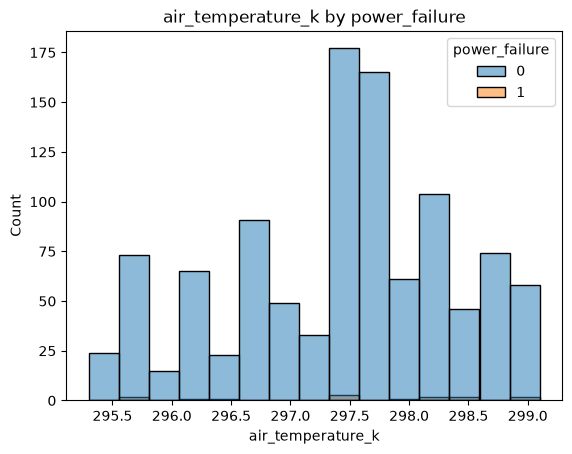

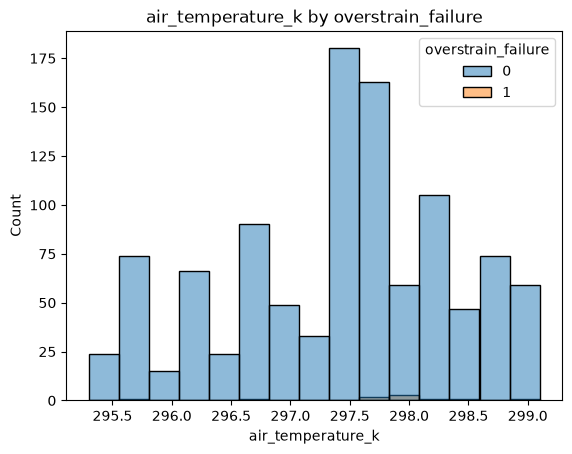

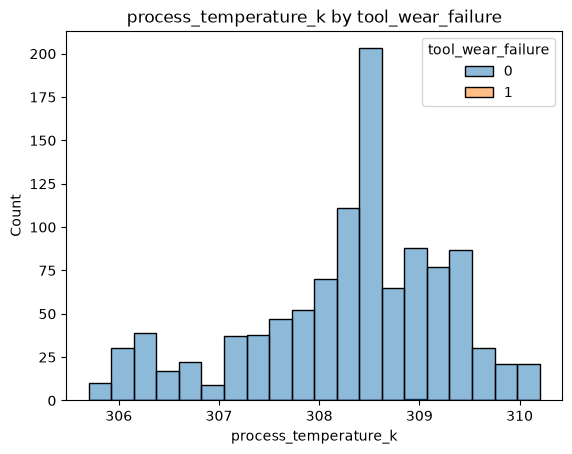

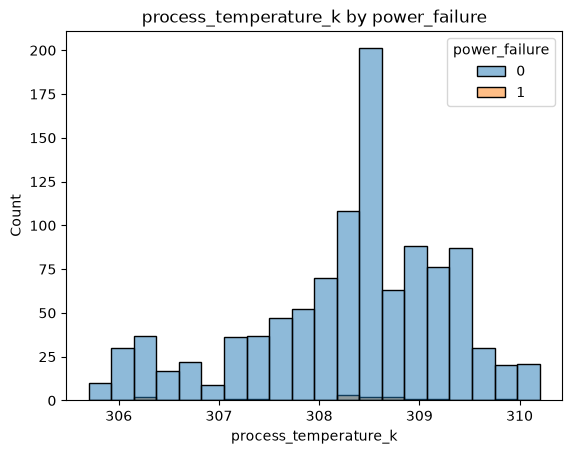

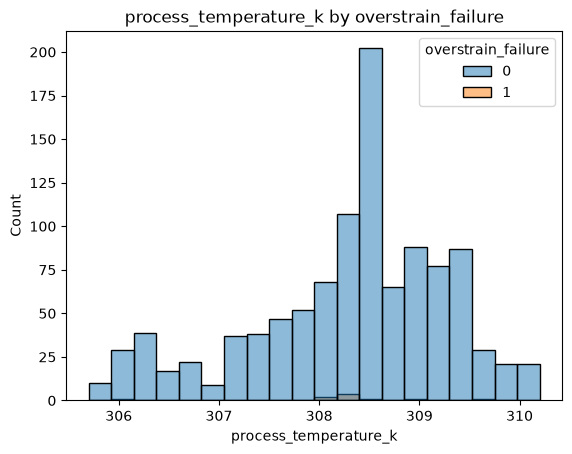

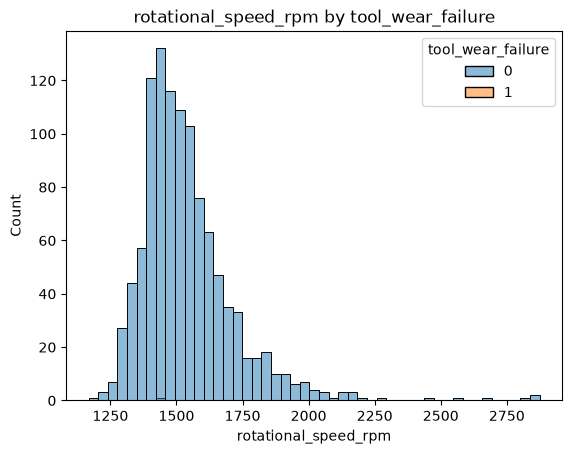

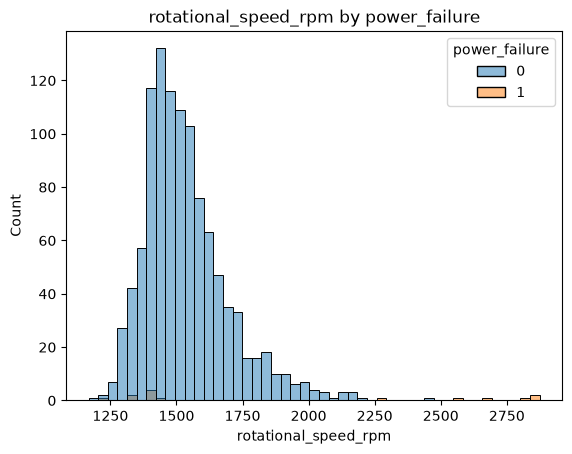

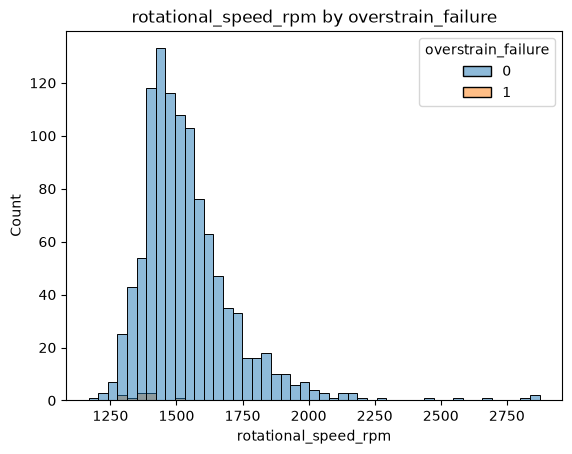

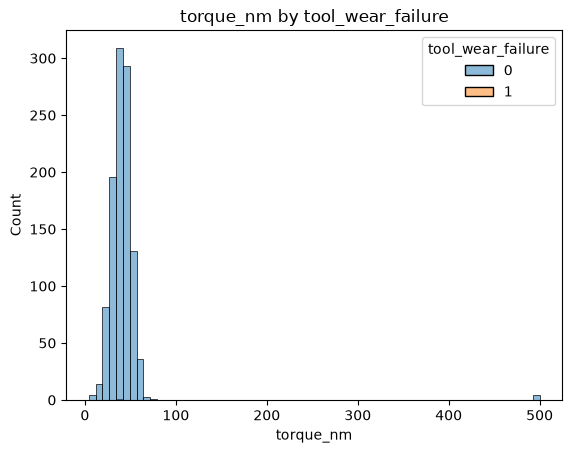

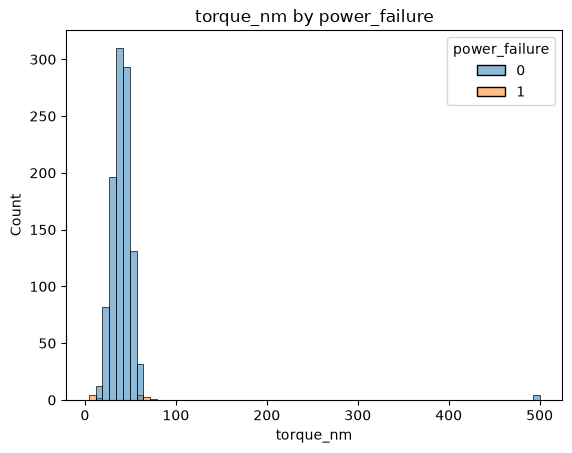

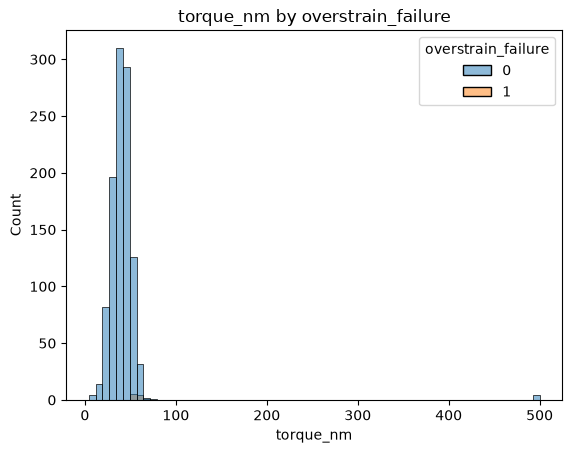

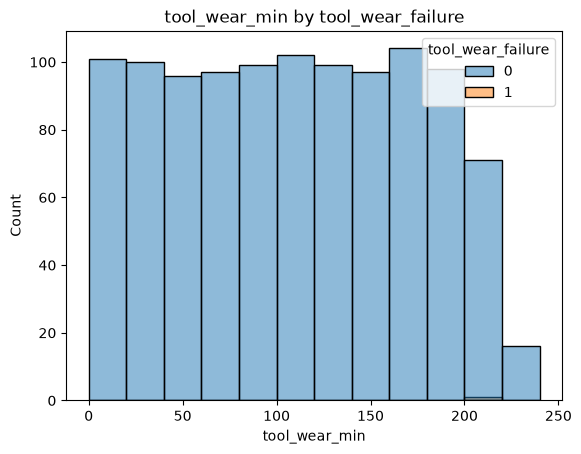

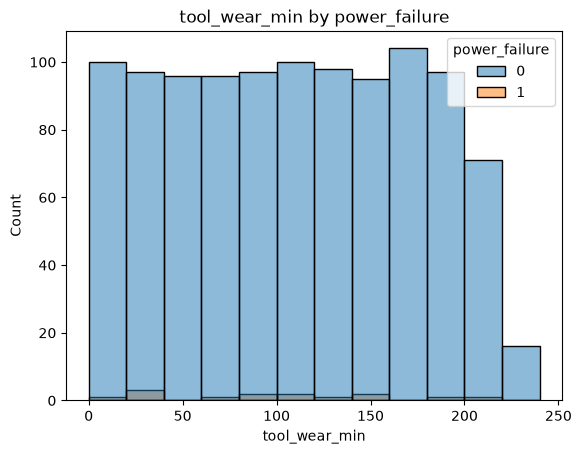

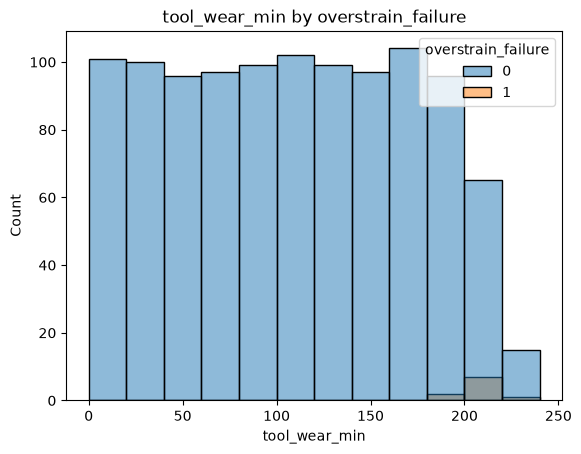

In [233]:

## Histogram for numerical values
## distribution of each feature by each machine_failure_type

for column in numerical_columns:
    for target in target_columns:
        plt.figure()

        sns.histplot(
        data=df,
        x=column,
        hue=target
        )
        plt.title(
            f"{column} by {target}"
        )
        

Observation:

- air_temperature_k: shows a multimodal shape and tool_wear_failure is rare, a very small percentage of power_failure scattered along the distribution, and a smaller percentage of overstrain_failure between 297.5 K and 298.3 K.
  
- process_temperature_k: multimodal and left-skewed, tool_wear_failure is rare, a few power_failures are observed between 306 K and 310 K and a few overstrain_failures are observed between 307 K and 310 K. 
  
- rotational_speed_rpm: right skewed with a few outliers, a few tool_wear_failure observed where rotational_speed_rpm count is the highest, a few power_failures scattered along the distribution, a few overstrain_failures are observed between 1250 RPM and 1550 RPM.

- torque_nm: bell shape, left skewed a little bit, tool_wear_failures are rare, a small percentage of power_failures are observed mainly around 5-25 N.m and 60-80 N.m, overstrain_failures occurs above approxiamately 50 N.m.

- tool_wear_min: rectangle shape, right skewed a little, tool_wear_failures are rare however there are a few observed between 200 min to 225 min, part of the few power_failures are scattered along the distribution and a few overstrain_failures are scattered from around 175 min to 245 min.

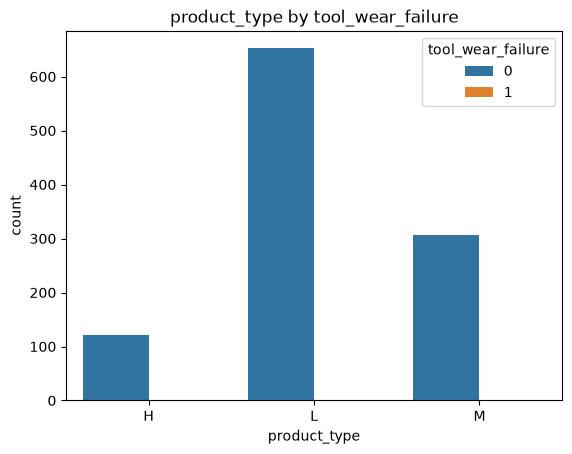

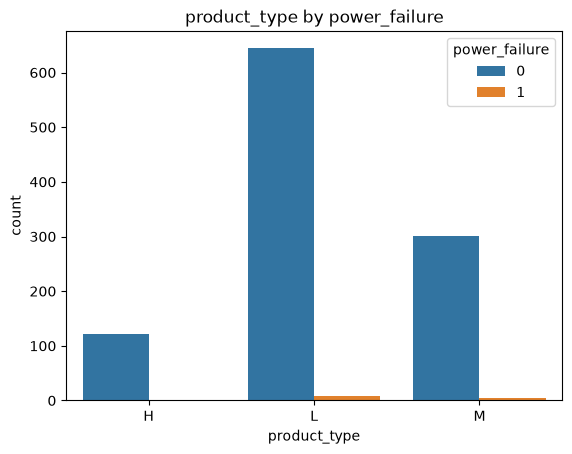

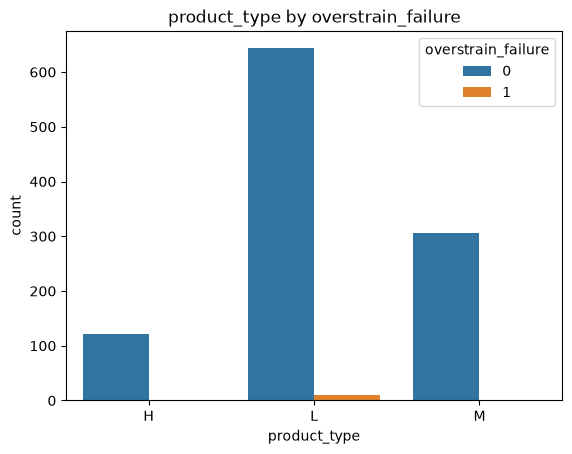

In [234]:
## Count plot (for catergorical features)

for column in categorical_columns:
    for target in target_columns:
        plt.figure()

        sns.countplot(
           data=df,
           x= column,
          hue=target
        )

        plt.title(f"{column} by {target}")
        plt.show

Observations (Product_type)

- tool_wear_failure: No tool_wear_failures associated with any product_type

- power_failure: power failure only occurs in product_type low (L) and medium (M)

- overstrain_failure: overstrain_failure only occurs in product type low
  
- OVERALL NO FAILURES ARE ASSOCIATED WITH product_type HIGHT (H)

OUTLIER DETECTION
- While observing the distribution graphs we have discoverd that some numerical columns may contain outliers

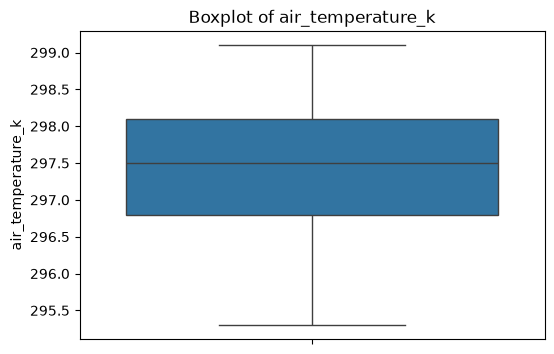

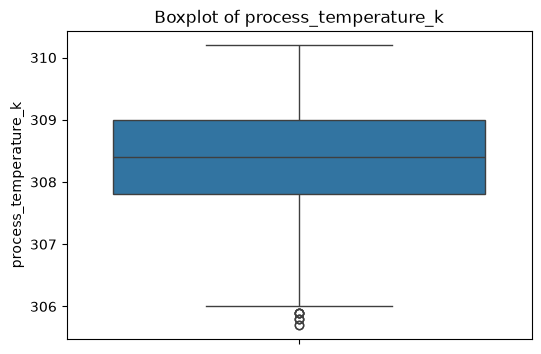

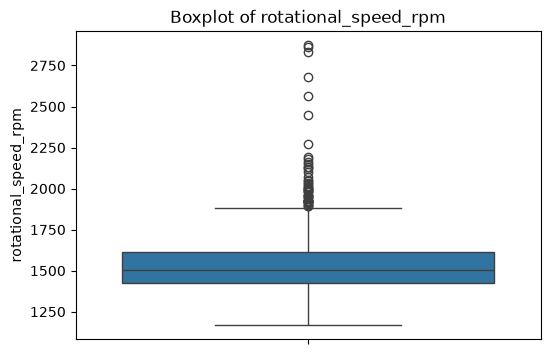

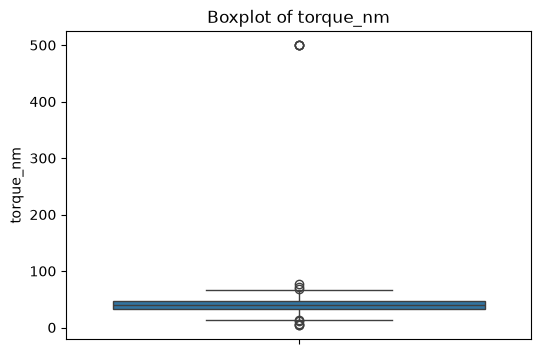

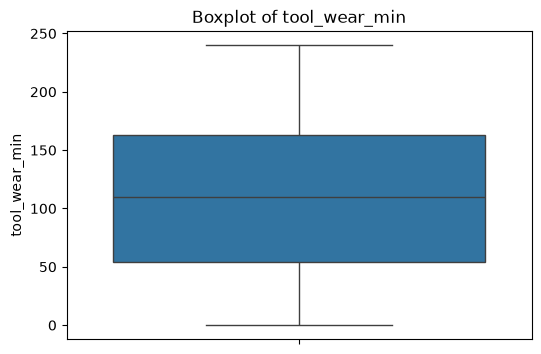

In [235]:
## Boxplot

for column in numerical_columns:

    plt.figure(figsize=(6,4))

    sns.boxplot( df[column])
    plt.title(f"Boxplot of {column}")

Observation:

- air_temperature_k: all values are within the whiskers, indicating that no outliers were detected
  
- process_temperature_k: a few values are clustered close to each other appear below the lower whisker, since these values are not extremely isolated this could suggest a natural variation

- rotational_speed_rpm: a few values are clustered close to each other above the upper whisker, these values do not appear to be isolated and this suggest a natural variation

- torque_nm: there are a few values that appear below the lower whisker and above the upper whisker these values are clustered close to each other, however ther is a single value that is isolated way above the other values above the upper whisker. this value was identified as an artificially introduced value during data preparation, therefore it will me removed

- tool_wear_min: all values are within the whiskers, indicating that no outliers were detected

REMOVING OUTLIERS

In [236]:
## Removing the artificially introduced torque value

df = df[df["torque_nm"] < 500]

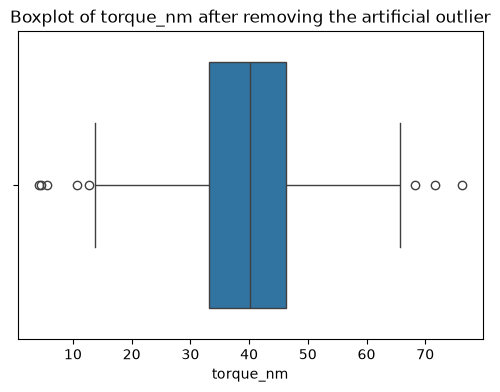

In [237]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["torque_nm"])
plt.title("Boxplot of torque_nm after removing the artificial outlier")
plt.show()

CORRELATION ANNALYSIS

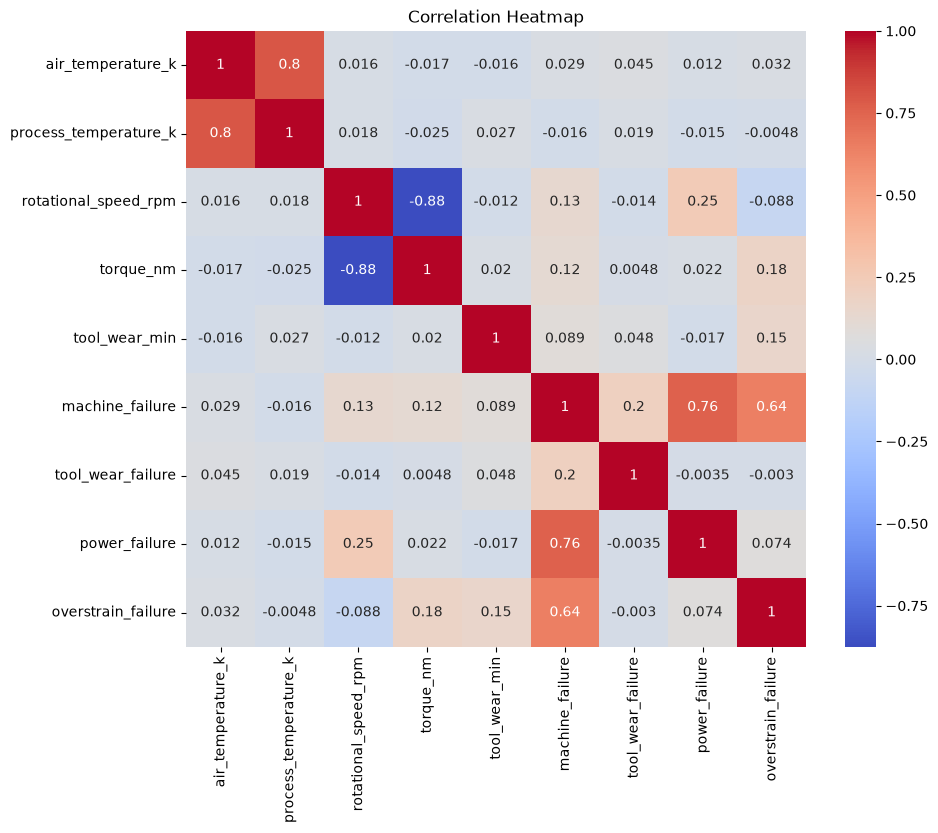

In [238]:
## Correlation Analysis for numerical values
## HEATMAP

plt.figure(figsize=(10,8))
    
sns.heatmap(
    df.corr( numeric_only = True),
    annot = True,
    cmap = "coolwarm"
)
plt.title(f"Correlation Heatmap")
plt.show()


Observation:

- process_temperature_k and air_temperature have a strong positive correlation of 0.8 which makes logical sense when surrounding air gets warmer process_temperature gets warmer too

- rotational_speed_rpm and torque_nm have a negative correlation , meaning they have an inverse relationship, these two features works together.

- failure_types: previous observation confirmed the relation we see between machine_failure and its failure_types, most machine_failures are related to power_failure

- the remaining features do not show any strong correlation and were therefore retained for model development

FEATURE ENGINEERING

In [239]:
## 

df["machine_operating_process_k"] = df["process_temperature_k"] - df["air_temperature_k"]

In [240]:
## 

df["machanical_power"] = df["torque_nm"] * df["rotational_speed_rpm"]

In [241]:
df.head()

,product_type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,tool_wear_failure,power_failure,overstrain_failure,machine_operating_process_k,machanical_power
0,H,298.4,308.9,1782.0,23.9,24,0,0,0,0,10.5,42589.8
1,H,298.6,309.1,1423.0,44.3,29,0,0,0,0,10.5,63038.9
2,H,298.8,309.2,1306.0,54.5,50,0,0,0,0,10.4,71177.0
3,H,298.9,309.3,1375.0,42.7,58,0,0,0,0,10.4,58712.5
4,H,299.1,309.4,1811.0,24.6,77,0,0,0,0,10.3,44550.6


# **PIPELINE BUILDING**

In [242]:
## Defining X and y

X = df.drop(columns=[
    "tool_wear_failure",
    "power_failure", 
    "overstrain_failure",
    ])

target_columns = [
    "tool_wear_failure", 
    "power_failure", 
    "overstrain_failure"]

y = df[target_columns]

TRAIN_TEST_SPLIT

In [243]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

PIPELINE and Preprocessing

In [244]:
numerical_features = [
    "air_temperature_k",
    "process_temperature_k",
    "rotational_speed_rpm",
    "torque_nm",
    "tool_wear_min",
    "machine_operating_process_k",
    "machanical_power"
    
]

categorical_features = [
    "product_type"
    ]


In [245]:
numerical_pipeline = Pipeline ([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures())
])

In [246]:
categorical_pipeline = Pipeline ([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
])

In [247]:
preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [248]:
## Preprocessing X_values

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print(X_train.shape)
print(X_train_preprocessed.shape)

(856, 9)
(856, 39)


# **NEURAL_NETWORK ARCHITECTURE**

In [249]:
## NEURAL_NETWORK ARCHITECTURE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.losses import BinaryFocalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

In [250]:
model = Sequential([
    Input(shape=(39,)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(3, activation="sigmoid")
])

In [251]:
## Handling class imbalanced

loss = BinaryFocalCrossentropy(
    apply_class_balancing = True,
    gamma=2.0
)

In [252]:
model.compile(
    optimizer=("adam"),
    loss=loss,
    metrics=["recall"]
)

EARLY STOPPING

In [253]:
## Early stopping stops training if model does not improve
early_stop = EarlyStopping(
    monitor = "val_loss",
    patience=10,
    restore_best_weights=True
)

MODEL CHECKPOINT 

In [254]:
## Model Checkpoint saves the best version of the model during training to the disk

checkpoint = ModelCheckpoint(
    filepath = "best_model.keras",
    monitor = "val_loss", 
    save_best_only =True,
    mode = "min",
    verbose = 1
)



In [255]:
callbacks = [
    early_stop, 
    checkpoint
]

## FITTING MODEL

In [256]:
history = model.fit(
    X_train_preprocessed,
    y_train,
    validation_split = 0.2,
    epochs = 100,
    batch_size = 32,
    callbacks = callbacks,
    verbose = 1
)

Epoch 1/100
18/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0403 - recall: 0.3333
Epoch 1: val_loss improved from None to 0.01241, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0361 - recall: 0.2857 - val_loss: 0.0124 - val_recall: 0.0000e+00
Epoch 2/100
19/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0109 - recall: 0.0000e+00   
Epoch 2: val_loss improved from 0.01241 to 0.01004, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0101 - recall: 0.0000e+00 - val_loss: 0.0100 - val_recall: 0.0000e+00
Epoch 3/100
17/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0037 - recall: 0.0000e+00 
Epoch 3: val_loss improved from 0.01004 to 0.00877, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0045 - recall: 0.0714 - val_loss: 0.0088 - va

## EVALUATION

In [294]:
from sklearn.metrics import (
                                f1_score,
                                precision_score,
                                recall_score,
                                accuracy_score,
                                classification_report,
                                roc_auc_score,
                                multilabel_confusion_matrix
                                
                            )

In [295]:
probabilities = model.predict(X_test_preprocessed)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step 


In [296]:
y_pred = (probabilities >= 0.5).astype(int)

In [297]:
def evaluate (y_test, y_pred, probabilities):
    results = {
        "F1 Score": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Classification report": classification_report(y_test, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, probabilities, average="weighted"),
        "Multilabel Confusion Matrix": multilabel_confusion_matrix(y_test, y_pred)
        
    }
    return results

In [298]:
evaluate (y_test, y_pred, probabilities)

c:\Users\Siphesihle\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Siphesihle\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


{'F1 Score': 0.5,
 'Precision': 1.0,
 'Recall': 0.3333333333333333,
 'Accuracy': 0.9813084112149533,
 'Classification report': '              precision    recall  f1-score   support\n\n           0       0.00      0.00      0.00         0\n           1       1.00      0.33      0.50         6\n           2       0.00      0.00      0.00         0\n\n   micro avg       1.00      0.33      0.50         6\n   macro avg       0.33      0.11      0.17         6\nweighted avg       1.00      0.33      0.50         6\n samples avg       0.01      0.01      0.01         6\n',
 'ROC AUC': 0.4166666666666667,
 'Multilabel Confusion Matrix': array([[[214,   0],
         [  0,   0]],
 
        [[208,   0],
         [  4,   2]],
 
        [[214,   0],
         [  0,   0]]])}